# Pakistan House Prediction — Industry-Style ML Workflow

**Goal:** Use the supplied Pakistan house dataset to demonstrate an end-to-end workflow: raw-data inspection → cleaning → EDA → missing values → duplicates/inconsistent formats → feature construction → train/validation/test split → preprocessing pipelines → one-hot encoding → StandardScaler / MinMaxScaler → model training → validation/tuning → final test evaluation.

This notebook follows the lifecycle in the Foundations of Machine Learning lecture: problem definition, data collection, cleaning, EDA, feature engineering, train/validation/test split, model selection, training, validation/tuning, final testing, deployment, and monitoring. The lecture explicitly emphasizes that train data teaches, validation tunes, and test data gives the final unbiased evaluation. [Course slide reference: Foundations of Machine Learning, lifecycle and split sections.]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_PATH = "pakistan house prediction dataset.csv"
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [2]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)

Shape: (1020, 15)

First 5 rows:


,ID,Area_SqFt,Bedrooms,Bathrooms,Floors,Year_Built,City,Location,Condition,Garage,Property_Type,Furnished,Corner_Property,Park_Facing,Price_PKR
0,662,720,1.0,1.0,2.0,"1,996",Karachi,dha phase 5,Fair,0.0,House,yes,no,NaN,"10,300,000"
1,669,9159 sqft,3.0,3.0,1.0,1985,NaN,North Nazimabad,Fair,0.0,House,no,No,NaN,82700000
2,62,3049,4.0,5.0,1.0,1989,Karachi,scheme 33,Excellent,1.0,Villa,no,no,No,20600000
3,415,2308.0,5.0,4.0,2.0,2005.0,Karachi,North Nazimabad,Fair,1.0,House,yes,NaN,NaN,28700000
4,936,2752 sqft,5.0,6.0,3.0,"1,985",Rawalpindi,Saddar,Poor,NaN,Villa,yes,yes,No,15700000.0



Data types:
ID                   int64
Area_SqFt           object
Bedrooms           float64
Bathrooms          float64
Floors             float64
Year_Built          object
City                object
Location            object
Condition           object
Garage             float64
Property_Type       object
Furnished           object
Corner_Property     object
Park_Facing         object
Price_PKR           object
dtype: object


In [3]:
print("Missing values by column:")
print(df.isna().sum())
print("\nTotal missing cells:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Missing values by column:
ID                   0
Area_SqFt           28
Bedrooms            32
Bathrooms           32
Floors              22
Year_Built          43
City                27
Location             0
Condition            0
Garage              41
Property_Type        0
Furnished          289
Corner_Property    339
Park_Facing        343
Price_PKR           25
dtype: int64

Total missing cells: 1221
Duplicate rows: 18


In [4]:
print("Unique values / cardinality:")
cardinality = pd.DataFrame({
    "unique_values": df.nunique(dropna=True),
    "dtype": df.dtypes.astype(str)
}).sort_values("unique_values", ascending=False)
print(cardinality.to_string())

Unique values / cardinality:
                 unique_values    dtype
ID                        1000    int64
Area_SqFt                  946   object
Price_PKR                  833   object
Location                   214   object
Year_Built                 164   object
Condition                   10   object
Bathrooms                    8  float64
Bedrooms                     7  float64
City                         5   object
Furnished                    5   object
Garage                       5  float64
Floors                       4  float64
Corner_Property              4   object
Park_Facing                  4   object
Property_Type                2   object


## 1. Problem definition

**Target:** `Price_PKR` — a numerical value, so this is a **regression** problem.

**Features (X):** property information such as area, bedrooms, bathrooms, city, location, condition, garage, property type, furnishing, corner property, and park facing.

The Foundations lecture defines regression as predicting a numerical target, such as house price, while classification predicts a category. This dataset therefore should be evaluated with regression metrics such as MAE, RMSE and R², not classification accuracy/precision/recall.

## 2. Raw-data quality audit

The raw CSV intentionally contains several real-world style issues: missing values, duplicate rows, inconsistent capitalization/whitespace, numbers stored as strings, units/commas embedded in numeric fields, and extreme values. The EDA lecture's workflow starts with shape, first rows and dtypes, then moves through univariate, bivariate and multivariate analysis.

In [5]:
# Show examples of messy numeric strings
for col in ["Area_SqFt", "Year_Built", "Price_PKR"]:
    print(f"\n {col} examples ")
    print(df[col].dropna().astype(str).head(15).tolist())


 Area_SqFt examples 
['720', '9159 sqft', '3049', '2308.0', '2752 sqft', '3,692', '2104.0', '1915 Sq. Ft.', '696.0', '2764', '770.0', '592 sq ft', ' 1802 ', '4748 sqft', ' 1396 ']

 Year_Built examples 
['1,996', ' 1985 ', '1989', '2005.0', '1,985', '2,019', '2020.0', '2,015', '2018', ' 2011 ', '2,004', '2012.0', '1998', ' 2003 ', '1994']

 Price_PKR examples 
['10,300,000', ' 82700000 ', ' 20600000 ', ' 28700000 ', '15700000.0', '31400000', '9900000', '23200000.0', '43,900,000', '16800000', ' 4500000 ', ' 29800000 ', '17100000', '34,800,000', ' 33200000 ']


In [6]:
# Inspect categorical inconsistencies
for col in ["City", "Condition", "Furnished", "Corner_Property", "Park_Facing"]:
    print(f"\n{col}: {df[col].dropna().astype(str).value_counts().head(15).to_dict()}")


City: {'Lahore': 297, 'Karachi': 275, 'Islamabad': 226, 'Rawalpindi': 117, 'Faisalabad': 78}

Condition: {'excellent': 123, 'Good': 113, 'Fair ': 110, 'GOOD': 105, 'Poor': 101, 'Fair': 100, 'Excellent': 98, 'New': 91, 'Needs Renovation': 90, 'good': 89}

Furnished: {'No': 163, 'yes': 161, 'no': 146, 'Yes': 139, 'YES': 122}

Corner_Property: {'yes': 193, 'No': 190, 'no': 157, 'Yes': 141}

Park_Facing: {'No': 183, 'no': 171, 'yes': 164, 'Yes': 159}


### Missingness mechanisms: MCAR, MAR, MNAR

These labels describe **why** values are missing, not how we fill them.

- **MCAR (Missing Completely At Random):** missingness is unrelated to observed or unobserved values.
- **MAR (Missing At Random):** missingness can be explained by other observed information.
- **MNAR (Missing Not At Random):** missingness is related to the unobserved/missing value itself.

A CSV alone cannot prove which mechanism generated a missing value. We can inspect patterns, but we should not claim that a particular column is definitely MCAR/MAR/MNAR without domain knowledge or a missingness study.

## 3. Cleaning deterministic formatting problems

First standardize obvious representation issues. This is not the same as statistical imputation: we are correcting strings such as `3,692`, `9159 sqft`, extra spaces, and inconsistent capitalization.

In [7]:
clean = df.copy()

# Standardize object columns: strip whitespace.
for col in clean.select_dtypes(include="object").columns:
    clean[col] = clean[col].str.strip() # remove unnecessary whitespace from the start and end of strings

# Normalize selected categorical text to lowercase.
for col in ["City", "Location", "Condition", "Furnished", "Corner_Property", "Park_Facing", "Property_Type"]:
    clean[col] = clean[col].str.lower()

# Convert messy numeric columns to numeric.
# Extract the numeric portion and remove comma separators.
for col in ["Area_SqFt", "Year_Built", "Price_PKR"]:
    clean[col] = (
        clean[col].astype("string")
        .str.replace(",", "", regex=False) 
        .str.extract(r"([-+]?\d*\.?\d+)", expand=False) # ya 25000 pkr maisa 25000 ko extract karta
    )
    clean[col] = pd.to_numeric(clean[col], errors="coerce") # coerce non-numeric values to NaN

print(clean.dtypes)
print(clean.head().to_string())

ID                   int64
Area_SqFt          Float64
Bedrooms           float64
Bathrooms          float64
Floors             float64
Year_Built         Float64
City                object
Location            object
Condition           object
Garage             float64
Property_Type       object
Furnished           object
Corner_Property     object
Park_Facing         object
Price_PKR          Float64
dtype: object
    ID  Area_SqFt  Bedrooms  Bathrooms  Floors  Year_Built        City         Location  Condition  Garage Property_Type Furnished Corner_Property Park_Facing   Price_PKR
0  662      720.0       1.0        1.0     2.0      1996.0     karachi      dha phase 5       fair     0.0         house       yes              no         NaN  10300000.0
1  669     9159.0       3.0        3.0     1.0      1985.0         NaN  north nazimabad       fair     0.0         house        no              no         NaN  82700000.0
2   62     3049.0       4.0        5.0     1.0      1989.0     karac

In [8]:
# Check invalid/impossible values before imputation.
checks = {
    "Area <= 0": int((clean["Area_SqFt"] <= 0).sum()),
    "Year_Built outside 1900-2026": int(((clean["Year_Built"] < 1900) | (clean["Year_Built"] > 2026)).sum()),
    "Bedrooms <= 0": int((clean["Bedrooms"] <= 0).sum()),
    "Bathrooms <= 0": int((clean["Bathrooms"] <= 0).sum()),
    "Floors <= 0": int((clean["Floors"] <= 0).sum()),
    "Price <= 0": int((clean["Price_PKR"] <= 0).sum()),
}
print(checks)

{'Area <= 0': 5, 'Year_Built outside 1900-2026': 0, 'Bedrooms <= 0': 0, 'Bathrooms <= 0': 0, 'Floors <= 0': 0, 'Price <= 0': 0}


In [ ]:
# Area = 0 cannot represent a usable house area, so treat it as missing.
clean.loc[clean["Area_SqFt"] <= 0, "Area_SqFt"] = np.nan # .loc[rows, columns] = specific rows + columns ko select/access karo. Jahan condition True hai, Area_SqFt column ko select karo or nan kr do

# Re-check missing values after converting invalid area values to NaN.
print(clean.isna().sum())

ID                   0
Area_SqFt           33
Bedrooms            32
Bathrooms           32
Floors              22
Year_Built          43
City                27
Location             0
Condition            0
Garage              41
Property_Type        0
Furnished          289
Corner_Property    339
Park_Facing        343
Price_PKR           25
dtype: int64


In [10]:
# Normalize binary categorical columns to yes/no where possible.
for col in ["Furnished", "Corner_Property", "Park_Facing"]:
    clean[col] = clean[col].replace({"y": "yes", "n": "no"})

print("Furnished:", clean["Furnished"].value_counts(dropna=False).to_dict())
print("Corner_Property:", clean["Corner_Property"].value_counts(dropna=False).to_dict())
print("Park_Facing:", clean["Park_Facing"].value_counts(dropna=False).to_dict())

Furnished: {'yes': 422, 'no': 309, nan: 289}
Corner_Property: {'no': 347, nan: 339, 'yes': 334}
Park_Facing: {'no': 354, nan: 343, 'yes': 323}


## 4. Duplicates

The raw dataset contains duplicate rows. Remove exact duplicate rows before splitting. Do not automatically remove records just because an `ID` repeats; that requires domain confirmation.

In [11]:
before = len(clean)
dup_count = int(clean.duplicated().sum())
clean = clean.drop_duplicates().reset_index(drop=True)

# A supervised model cannot train when the target itself is missing.
# We remove only rows with missing Price_PKR; feature missingness is handled later in the pipeline.
missing_target = int(clean["Price_PKR"].isna().sum())
clean = clean.dropna(subset=["Price_PKR"]).reset_index(drop=True)
print("Rows before:", before)
print("Exact duplicate rows removed:", dup_count)
print("Rows with missing target removed:", missing_target)
print("Rows after:", len(clean))

Rows before: 1020
Exact duplicate rows removed: 18
Rows with missing target removed: 25
Rows after: 977


## 5. EDA — shape → describe → univariate → bivariate → multivariate → summary

This sequence mirrors the supplied EDA guided-practice deck. The deck demonstrates `shape`, `head`, `dtypes`, `describe`, category counts, histograms, grouped means, scatterplots and correlation heatmaps.

In [12]:
print(clean.describe(include="all").T)

                 count unique          top  freq             mean  \
ID               977.0    NaN          NaN   NaN       500.545548   
Area_SqFt        945.0   <NA>         <NA>  <NA>       3271.97037   
Bedrooms         947.0    NaN          NaN   NaN         3.940866   
Bathrooms        946.0    NaN          NaN   NaN         3.960888   
Floors           956.0    NaN          NaN   NaN          1.85251   
Year_Built       934.0   <NA>         <NA>  <NA>      2005.153105   
City               954      5       lahore   285              NaN   
Location           977     46  bahria town    59              NaN   
Condition          977      6         good   295              NaN   
Garage           937.0    NaN          NaN   NaN         1.488794   
Property_Type      977      2        house   732              NaN   
Furnished          701      2          yes   406              NaN   
Corner_Property    651      2           no   327              NaN   
Park_Facing        647      2     

In [13]:
# Univariate: categorical counts
for col in ["City", "Condition", "Property_Type"]:
    print(f"\n{col} counts:")
    print(clean[col].value_counts(dropna=False).head(15))


City counts:
City
lahore        285
karachi       264
islamabad     214
rawalpindi    114
faisalabad     77
NaN            23
Name: count, dtype: int64

Condition counts:
Condition
good                295
excellent           208
fair                202
poor                100
new                  89
needs renovation     83
Name: count, dtype: int64

Property_Type counts:
Property_Type
house    732
villa    245
Name: count, dtype: int64


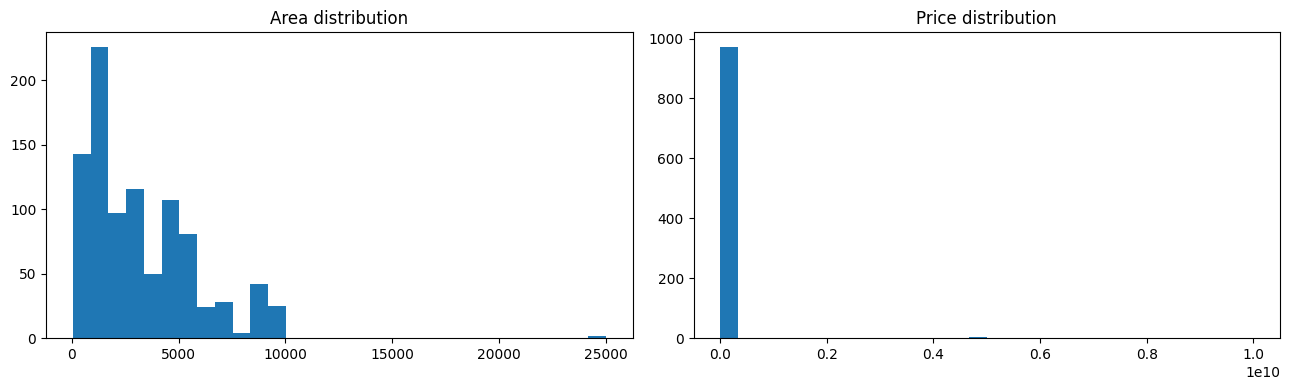

In [14]:
# Univariate: numerical distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(clean["Area_SqFt"].dropna(), bins=30)
axes[0].set_title("Area distribution")
axes[1].hist(clean["Price_PKR"].dropna(), bins=30)
axes[1].set_title("Price distribution")
plt.tight_layout()
plt.show()

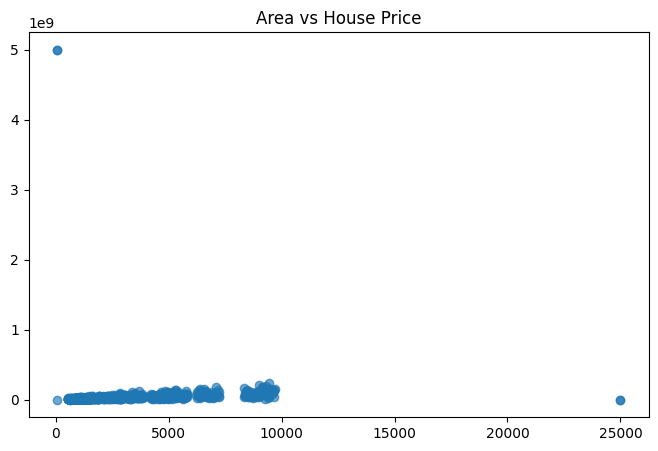

Correlation (Area vs Price): 0.03861154093381776


In [15]:
# Bivariate: area vs price
plt.figure(figsize=(8, 5))
plt.scatter(clean["Area_SqFt"], clean["Price_PKR"], alpha=0.65)
plt.title("Area vs House Price")
plt.show()

print("Correlation (Area vs Price):", clean[["Area_SqFt", "Price_PKR"]].corr().iloc[0,1])

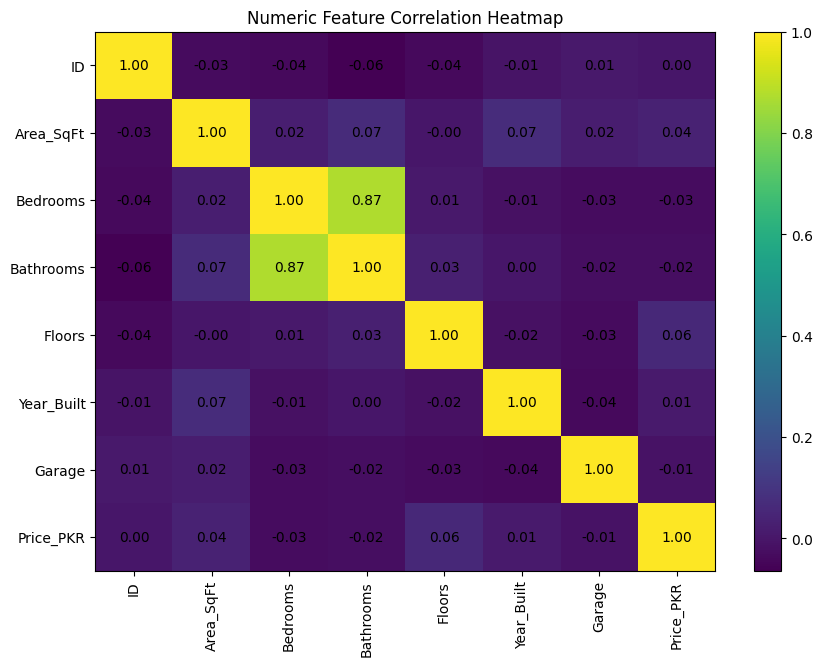

In [16]:
# Multivariate: correlation heatmap for numeric columns
numeric_for_corr = clean.select_dtypes(include=np.number)
plt.figure(figsize=(10, 7))
corr = numeric_for_corr.corr()
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")
plt.title("Numeric Feature Correlation Heatmap")
plt.show()

In [17]:
# Skewness inspection
numeric_cols = clean.select_dtypes(include=np.number).columns
skew_table = clean[numeric_cols].skew().sort_values(key=lambda s: s.abs(), ascending=False)
print("Skewness:")
print(skew_table)

Skewness:
Price_PKR     16.415698
Area_SqFt      1.909216
Floors          0.64389
Garage         0.320004
Bedrooms      -0.064183
Year_Built    -0.059651
Bathrooms     -0.017082
ID              0.00408
dtype: Float64


### Skew and outliers

Skewness describes asymmetry of a distribution. A right-skewed price distribution can happen naturally because a small number of expensive properties have very high prices.

Outliers are observations that are unusually extreme. An outlier is **not automatically an error**. A genuine luxury property can be expensive. We therefore flag extremes and inspect them instead of deleting them blindly.

In [18]:
# IQR-based outlier flagging for selected numeric variables.
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ["Area_SqFt", "Price_PKR"]:
    s = clean[col].dropna()
    low, high = iqr_bounds(s)
    count = int(((clean[col] < low) | (clean[col] > high)).sum())
    print(f"{col}: lower={low:,.2f}, upper={high:,.2f}, flagged={count}")

Area_SqFt: lower=-4,220.50, upper=10,223.50, flagged=2
Price_PKR: lower=-35,800,000.00, upper=102,600,000.00, flagged=58


## 6. Feature construction

Create useful features from existing information. These are derived from input columns only, so they do not use the target.

- `House_Age = 2026 - Year_Built`
- `Total_Rooms = Bedrooms + Bathrooms`
- `Area_per_Bedroom = Area_SqFt / Bedrooms`
- `Has_Garage = 1 if Garage > 0 else 0`

Feature engineering means creating or transforming inputs into representations that help a model learn the task.

In [19]:
clean["House_Age"] = 2026 - clean["Year_Built"]
clean["Total_Rooms"] = clean["Bedrooms"] + clean["Bathrooms"]
clean["Area_per_Bedroom"] = clean["Area_SqFt"] / clean["Bedrooms"].replace(0, np.nan)
clean["Has_Garage"] = (clean["Garage"] > 0).astype(float)

print(clean[["Year_Built", "House_Age", "Bedrooms", "Bathrooms", "Total_Rooms", "Area_SqFt", "Area_per_Bedroom", "Garage", "Has_Garage"]].head().to_string())

   Year_Built  House_Age  Bedrooms  Bathrooms  Total_Rooms  Area_SqFt  Area_per_Bedroom  Garage  Has_Garage
0      1996.0       30.0       1.0        1.0          2.0      720.0             720.0     0.0         0.0
1      1985.0       41.0       3.0        3.0          6.0     9159.0            3053.0     0.0         0.0
2      1989.0       37.0       4.0        5.0          9.0     3049.0            762.25     1.0         1.0
3      2005.0       21.0       5.0        4.0          9.0     2308.0             461.6     1.0         1.0
4      1985.0       41.0       5.0        6.0         11.0     2752.0             550.4     NaN         0.0


## 7. Train / validation / test split

The supplied Foundations lecture uses a 70/15/15 example: training teaches, validation chooses/tunes, and test provides the final unbiased evaluation. We will reproduce that protocol here.

In [20]:
# Drop target and ID from X. ID is an identifier, not a meaningful predictive measurement.
X = clean.drop(columns=["Price_PKR", "ID"])
y = clean["Price_PKR"]

# First: 70% train, 30% temporary.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Then split the temporary 30% equally: 15% validation, 15% test.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (683, 17) (683,)
Validation: (147, 17) (147,)
Test: (147, 17) (147,)


## 8. Preprocessing pipelines

A pipeline chains preprocessing and model steps so the same transformations are learned from training data and then applied consistently to validation/test data. This helps prevent leakage from fitting imputers, encoders or scalers on the full dataset.

In [21]:
numeric_features = [
    "Area_SqFt", "Bedrooms", "Bathrooms", "Floors", "Year_Built", "Garage",
    "House_Age", "Total_Rooms", "Area_per_Bedroom", "Has_Garage"
]

categorical_features = [
    "City", "Location", "Condition", "Property_Type", "Furnished",
    "Corner_Property", "Park_Facing"
]

numeric_standard_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_minmax_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_standard = ColumnTransformer([
    ("num", numeric_standard_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor_minmax = ColumnTransformer([
    ("num", numeric_minmax_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("StandardScaler and MinMaxScaler pipelines created.")

StandardScaler and MinMaxScaler pipelines created.


### StandardScaler vs MinMaxScaler

**StandardScaler:** transforms using `(x - mean) / standard_deviation`, giving each numeric feature a mean around 0 and standard deviation around 1 on the fitted training data.

**MinMaxScaler:** maps values using the training minimum and maximum, commonly to the 0–1 range.

One-hot encoded columns are already 0/1, so we do not apply continuous scaling to them in this pipeline.

In [22]:
# Demonstrate the two scaling methods on one raw numeric column using TRAINING data only.
area_train = X_train[["Area_SqFt"]].copy()

std_demo = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
mm_demo = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

std_values = std_demo.fit_transform(area_train).ravel()
mm_values = mm_demo.fit_transform(area_train).ravel()

print("Standard-scaled first 5 Area values:", np.round(std_values[:5], 3))
print("Min-max-scaled first 5 Area values:", np.round(mm_values[:5], 3))

Standard-scaled first 5 Area values: [-0.721 -0.704 -0.68  -0.417  0.792]
Min-max-scaled first 5 Area values: [0.054 0.056 0.059 0.087 0.216]


## 9. Model training — regression

Because the target is house price, we use regression models. We will compare a simple baseline (Linear Regression) with KNN Regression, Decision Tree Regression and Random Forest Regression. The Foundations lecture explains that algorithm choice depends on whether the target is categorical or numerical.

In [23]:
models = {
    "Linear Regression": Pipeline([
        ("preprocess", preprocessor_standard),
        ("model", LinearRegression())
    ]),
    "KNN Regression": Pipeline([
        ("preprocess", preprocessor_standard),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ]),
    "Decision Tree": Pipeline([
        ("preprocess", preprocessor_standard),
        ("model", DecisionTreeRegressor(max_depth=8, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocess", preprocessor_standard),
        ("model", RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1))
    ])
}

results = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_val, pred),
        "RMSE": np.sqrt(mean_squared_error(y_val, pred)),
        "R2": r2_score(y_val, pred)
    })

val_results = pd.DataFrame(results).sort_values("RMSE")
print(val_results.to_string(index=False))

            Model          MAE         RMSE         R2
    Decision Tree 1.461972e+07 2.316435e+07   0.583480
   KNN Regression 1.597075e+07 2.479310e+07   0.522847
    Random Forest 3.398861e+07 1.791172e+08 -23.904055
Linear Regression 1.100526e+08 1.964548e+08 -28.958552


## 10. Hyperparameter tuning with validation / cross-validation

Parameters are learned from training data. Hyperparameters are choices made by us/model-development procedure, such as K in KNN or `max_depth` in a tree. We use cross-validation **inside the training portion** for tuning so the final test set remains untouched.

In [24]:
# Tune Random Forest using 5-fold CV on TRAINING data only.
rf_pipe = Pipeline([
    ("preprocess", preprocessor_standard),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [8, 12]
}

grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

val_pred_tuned = grid.predict(X_val)
print("Validation MAE:", mean_absolute_error(y_val, val_pred_tuned))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, val_pred_tuned)))
print("Validation R2:", r2_score(y_val, val_pred_tuned))

Best hyperparameters: {'model__max_depth': 12, 'model__n_estimators': 100}
Best CV RMSE: 405303999.8551283
Validation MAE: 34387455.236739464
Validation RMSE: 178403113.7627584
Validation R2: -23.705894050329462


## 11. Highly skewed target: log transformation

The EDA shows that `Price_PKR` is strongly right-skewed. Rather than deleting genuine expensive properties just because they are extreme, we can test a log-target approach. `TransformedTargetRegressor` trains on `log1p(y)` and converts predictions back with `expm1`. This is a modeling choice, not a claim that every outlier is bad data.

In [25]:
log_rf = TransformedTargetRegressor(
    regressor=Pipeline([
        ("preprocess", preprocessor_standard),
        ("model", RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

log_rf.fit(X_train, y_train)
log_val_pred = log_rf.predict(X_val)
print("Log-target validation MAE:", mean_absolute_error(y_val, log_val_pred))
print("Log-target validation RMSE:", np.sqrt(mean_squared_error(y_val, log_val_pred)))
print("Log-target validation R2:", r2_score(y_val, log_val_pred))

# Keep this model as the selected candidate for final test evaluation because it was chosen using validation performance.
final_model = log_rf

Log-target validation MAE: 11735620.704687739
Log-target validation RMSE: 19538871.71781752
Log-target validation R2: 0.7036569969394066


## 11. Final test evaluation

After choosing/tuning using training + validation information, evaluate the selected pipeline on the untouched test set once. This is the closest thing in this workflow to the lecture's final unbiased evaluation.

Final test metrics:
MAE: 78625499.88324824
RMSE: 581679125.3768966
R2: -0.020375652036537906


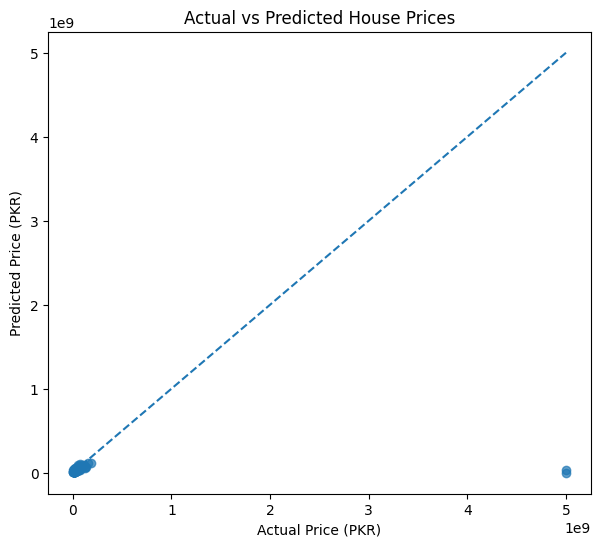

In [26]:
test_pred = final_model.predict(X_test)

final_metrics = pd.DataFrame([{
    "MAE": mean_absolute_error(y_test, test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
    "R2": r2_score(y_test, test_pred)
}])

print("Final test metrics:")
print("MAE:", final_metrics.loc[0, "MAE"])
print("RMSE:", final_metrics.loc[0, "RMSE"])
print("R2:", final_metrics.loc[0, "R2"])

plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred, alpha=0.7)
min_v = min(y_test.min(), test_pred.min())
max_v = max(y_test.max(), test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.xlabel("Actual Price (PKR)")
plt.ylabel("Predicted Price (PKR)")
plt.title("Actual vs Predicted House Prices")
plt.show()

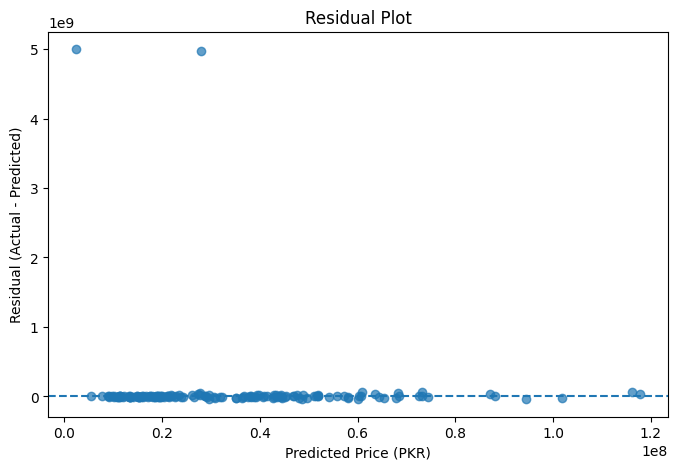

Mean residual: 69605741.47949795


In [27]:
# Residual analysis: residual = actual - predicted
residuals = y_test - test_pred

plt.figure(figsize=(8, 5))
plt.scatter(test_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price (PKR)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

print("Mean residual:", residuals.mean())

## 12. Feature selection — practical version

Feature selection means deciding which input variables should be kept. First use domain logic and data quality: an identifier like `ID` is excluded because it is an identifier rather than a property characteristic. For more formal selection, methods such as correlation screening, mutual information, or model-based importance can be used **inside a training-only workflow** so that the test set is not used to select features.

In [28]:
# Simple training-only correlation screening for numeric features.
train_numeric = X_train[numeric_features].copy()
train_numeric["Price_PKR"] = y_train.values
corr_to_target = train_numeric.corr(numeric_only=True)["Price_PKR"].drop("Price_PKR").sort_values(key=lambda s: s.abs(), ascending=False)
print("Numeric feature correlations with target (training set only):")
print(corr_to_target)

Numeric feature correlations with target (training set only):
House_Age          -0.057861
Year_Built          0.057861
Floors              0.056470
Area_SqFt           0.056230
Total_Rooms        -0.054210
Bathrooms          -0.052253
Bedrooms           -0.051934
Area_per_Bedroom    0.038765
Has_Garage          0.032354
Garage             -0.001715
Name: Price_PKR, dtype: float64


## 13. TF-IDF and N-grams — when they apply

The supplied house dataset has categorical `Location`, but it does **not** contain a genuine free-text description column. Therefore, applying TF-IDF to `Location` as if it were natural language would be a modeling choice that changes the meaning of the variable.

For learning purposes, here is a separate small text example. **Do not add this to the house-price pipeline unless a real text-description column is available.**

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = [
    "beautiful modern house",
    "beautiful house in Lahore",
    "old house needs renovation",
    "modern villa in Lahore"
]

vectorizer = TfidfVectorizer(ngram_range=(1, 2))  # unigrams + bigrams
X_text = vectorizer.fit_transform(texts)

text_features = pd.DataFrame(
    X_text.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print(text_features.round(3).to_string())

   beautiful  beautiful house  beautiful modern  house  house in  house needs     in  in lahore  lahore  modern  modern house  modern villa  needs  needs renovation    old  old house  renovation  villa  villa in
0      0.413            0.000             0.523  0.334     0.000        0.000  0.000      0.000   0.000   0.413         0.523         0.000  0.000             0.000  0.000      0.000       0.000  0.000     0.000
1      0.356            0.452             0.000  0.289     0.452        0.000  0.356      0.356   0.356   0.000         0.000         0.000  0.000             0.000  0.000      0.000       0.000  0.000     0.000
2      0.000            0.000             0.000  0.252     0.000        0.395  0.000      0.000   0.000   0.000         0.000         0.000  0.395             0.395  0.395      0.395       0.395  0.000     0.000
3      0.000            0.000             0.000  0.000     0.000        0.000  0.337      0.337   0.337   0.337         0.000         0.427  0.000      

### N-gram reminder

- **Unigram:** one token, e.g. `good`
- **Bigram:** two consecutive tokens, e.g. `not good`
- **Trigram:** three consecutive tokens, e.g. `not very good`

TF-IDF gives terms weights based on their frequency in a document and their rarity across documents. Common terms tend to receive lower IDF contribution than distinctive terms.

## 14. Classification metrics — why they are NOT used for this target

Your lecture discusses confusion matrices, TP, TN, FP, FN, accuracy, precision, recall and thresholds. Those are central to classification problems such as Pass/Fail or Spam/Not Spam.

This house-price task is regression, so there is no TP/TN/FP/FN confusion matrix for the price itself. The appropriate evaluation here is MAE, RMSE and R². If you later build a separate classification target such as `High_Price` vs `Normal_Price`, then a confusion matrix and classification metrics would become appropriate.

## 15. Data leakage checklist

Before finalizing a model, ask:

1. Did I fit the imputer using only training data?
2. Did I fit the scaler using only training data?
3. Did I fit the encoder using only training data?
4. Did I tune hyperparameters without using the final test set?
5. Did I avoid using the target to construct input features?
6. Did I keep the test set untouched until final evaluation?

Using `Pipeline` + `ColumnTransformer` + train/validation/test separation is the clean way to enforce this.

## 16. Final industry-style checklist

**Raw data → Inspect → Clean → EDA → Construct features → Split → Pipeline → Impute → Encode → Scale → Train → Validate/Tune → Final Test → Evaluate → Deploy → Monitor/Retrain.**

The Foundations lecture describes deployment and monitoring/retraining as later stages of the lifecycle. In a real system, the job does not end when the notebook gets a good score; incoming data can change over time, so monitoring and retraining may be required.